# Phase 1 — Choosing the race, and the drivers

The brief asks for *one dry race with no red flags* and *5 to 10 drivers who completed it*.
Both choices are made from the data rather than from memory, because the obvious pick turns
out to be wrong.

## The question this project answers

> Within one dry Grand Prix, does a lap time model improve when it knows how old the tires
> are, after fuel burn and grid position are already accounted for, and is that improvement
> real or an artifact of how the data was split?

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

## 1. Scoring every race of the season

Four signals, all visible in the lap data itself:

| Signal | Meaning | Want |
| :-- | :-- | :-- |
| `wet_score` | mean per-driver coefficient of variation of lap times | low |
| `disruption` | share of laps slower than 1.5x the field median | low |
| `max_spike` | slowest field-median lap, as a multiple of the race median | low |
| `attrition` | largest single-lap drop in cars running, mid-race only | low |
| `usable_drivers` | finishers with at least two stints | high |

In [2]:
from race_selection import rank_season

ranking = rank_season(2019)
(ROOT / "results").mkdir(exist_ok=True)
ranking.to_csv(ROOT / "results" / "race_selection_2019.csv", index=False)

ranking[[
    "round", "name", "total_laps", "wet_score", "disruption",
    "max_spike", "attrition", "usable_drivers", "viable",
]]

,round,name,total_laps,wet_score,disruption,max_spike,attrition,usable_drivers,viable
11,12,Hungarian Grand Prix,70,0.0369,0.0000,1.139,1,14,True
18,19,United States Grand Prix,56,0.0373,0.0000,1.073,1,15,True
8,9,Austrian Grand Prix,71,0.0375,0.0000,1.115,0,17,True
20,21,Abu Dhabi Grand Prix,55,0.0369,0.0009,1.085,1,17,True
16,17,Japanese Grand Prix,52,0.0382,0.0000,1.066,1,15,True
6,7,Canadian Grand Prix,70,0.0388,0.0008,1.149,1,15,True
7,8,French Grand Prix,53,0.0407,0.0000,1.138,1,17,True
0,1,Australian Grand Prix,58,0.0433,0.0019,1.135,1,15,True
2,3,Chinese Grand Prix,56,0.0510,0.0000,1.203,1,15,False
13,14,Italian Grand Prix,53,0.0606,0.0000,1.250,1,16,False


### Two traps this scoring had to avoid

**Finishing is not retirement.** A first attempt measured red flags as the largest drop in
the number of cars circulating between consecutive laps. That flags almost every clean race,
because the leader completes more laps than the cars they lapped, so the field appears to
collapse at the flag. Attrition is therefore measured only up to three laps from the end.

**Wetness has to be a gate, not a tiebreaker.** With wetness used only for ranking, the 2019
German Grand Prix passed the filter: its disruption and attrition are low. It was the wettest
race of the season, with 78 pit stops. `wet_score` is now a hard threshold.

### Why not Bahrain

The Bahrain Grand Prix is the natural first choice and it fails: a `max_spike` of 1.345 and
three mid-race retirements, reflecting the late safety car and the leader's engine failure.
Its laps would carry neutralised running that has nothing to do with tire wear.

In [3]:
ranking[ranking["name"].str.contains("Bahrain|German|United States")][[
    "name", "wet_score", "disruption", "max_spike", "attrition", "viable",
]]

,name,wet_score,disruption,max_spike,attrition,viable
18,United States Grand Prix,0.0373,0.0000,1.073,1,True
1,Bahrain Grand Prix,0.0794,0.0028,1.345,3,False
10,German Grand Prix,0.1572,0.0114,1.437,1,False


## 2. Choosing among the survivors on stint structure

Eight races pass. The tiebreaker is experimental design, because the final stint becomes the
test set:

- The **2019 Austrian Grand Prix** is just as clean and has 17 usable drivers, but nearly
  every driver ran one stop. That gives a single training stint per driver, and its long
  final stints would make the test set *larger* than the training set.
- The **2019 United States Grand Prix** has most finishers on three stints: two training
  stints and one held-out final stint each, at roughly a 60/40 split of laps. It also has the
  lowest lap-time spike of the entire season, 1.073x the race median, so no safety car ever
  flattened the pace.

Austin is chosen.

In [4]:
from dataset import build_lap_table

race, selected, laps = build_lap_table()

print(f"{race['name']} {race['year']}  |  raceId {race['raceId']}  |  {race['date']}")
print(f"{int(laps['total_laps'].iloc[0])} laps")
selected[["code", "surname", "grid", "finish_position", "n_stints", "train_laps", "test_laps"]]

United States Grand Prix 2019  |  raceId 1028  |  2019-11-03
56 laps


,code,surname,grid,finish_position,n_stints,train_laps,test_laps
0,BOT,Bottas,1,1,3,35,21
1,HAM,Hamilton,5,2,2,24,32
2,VER,Verstappen,3,3,3,34,22
3,LEC,Leclerc,4,4,3,42,14
4,ALB,Albon,6,5,4,40,16
5,RIC,Ricciardo,9,6,2,21,35
6,NOR,Norris,8,7,3,42,14
7,HUL,Hülkenberg,11,9,3,39,17


Eight drivers, the highest finishers who each have at least 10 laps in the final stint and
at least 20 before it. Those thresholds exist so every driver contributes a test stint worth
measuring.

In [5]:
print(f"{len(laps):,} laps across {laps['driverId'].nunique()} drivers")
print(f"uncleaned median lap {laps['seconds'].median():.3f}s")
laps.head()

447 laps across 8 drivers
uncleaned median lap 100.861s


,raceId,driverId,lap,position,time,milliseconds,seconds,code,surname,grid,finish_position,total_laps
0,1028,1,1,3,1:43.228,103228,103.228,HAM,Hamilton,5,2,56
1,1028,1,2,3,1:41.043,101043,101.043,HAM,Hamilton,5,2,56
2,1028,1,3,3,1:41.259,101259,101.259,HAM,Hamilton,5,2,56
3,1028,1,4,3,1:41.231,101231,101.231,HAM,Hamilton,5,2,56
4,1028,1,5,3,1:40.861,100861,100.861,HAM,Hamilton,5,2,56


## 3. Sanity check before any cleaning

Raw lap times, one line per driver. The expected shape is a sawtooth: pace decays through a
stint as the tires wear, then a tall spike marks the lap the car came into the pits, then the
pattern restarts on fresh rubber. Those spikes are what Phase 2 removes.

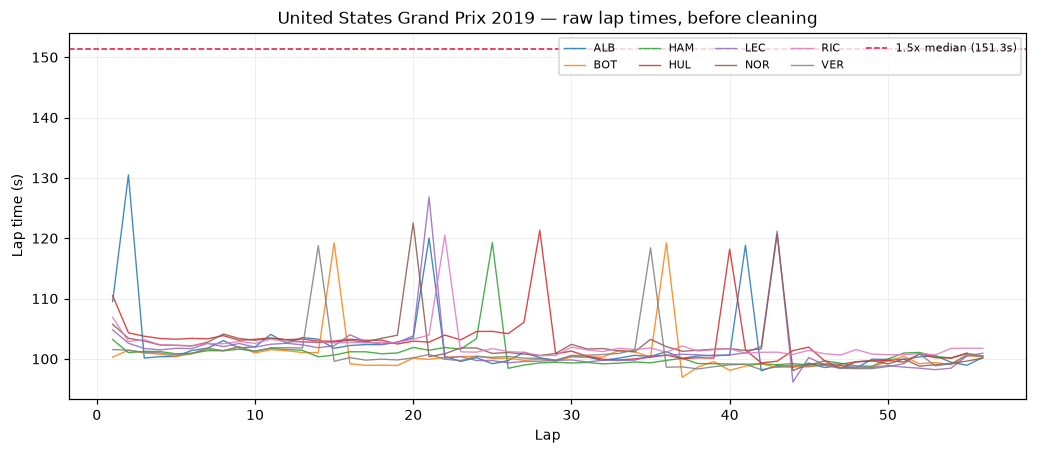

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))

for code, grp in laps.groupby("code"):
    ax.plot(grp["lap"], grp["seconds"], lw=0.9, alpha=0.85, label=code)

median = laps["seconds"].median()
ax.axhline(1.5 * median, color="crimson", ls="--", lw=1,
           label=f"1.5x median ({1.5 * median:.1f}s)")

ax.set_xlabel("Lap")
ax.set_ylabel("Lap time (s)")
ax.set_title(f"{race['name']} {race['year']} — raw lap times, before cleaning")
ax.legend(ncol=5, fontsize=7, loc="upper right")
ax.grid(alpha=0.25, lw=0.5)
fig.tight_layout()

(ROOT / "figures").mkdir(exist_ok=True)
fig.savefig(ROOT / "figures" / "01_raw_lap_times.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
above = (laps["seconds"] > 1.5 * median).sum()
print(f"laps above the 1.5x line: {above}  ({above / len(laps):.1%})")
print(f"slowest lap: {laps['seconds'].max():.1f}s   fastest lap: {laps['seconds'].min():.3f}s")

laps.to_csv(ROOT / "results" / "laps_raw_selected.csv", index=False)
print(f"\nsaved {len(laps):,} rows to results/laps_raw_selected.csv")

laps above the 1.5x line: 0  (0.0%)
slowest lap: 130.5s   fastest lap: 96.169s

saved 447 rows to results/laps_raw_selected.csv


---

**Phase 1 complete.** The race is the 2019 United States Grand Prix, chosen on measured
wetness, disruption and stint structure rather than reputation. Eight drivers are selected,
each with enough laps before and after their final pit stop to support a held-out stint.

Phase 2 removes pit laps, out-laps and outliers, and reports the count of each.